# 1D Obstacle Solver

# Numba Version for large N

In [1]:
"""
Gaussian-RBF ADMM (1-D obstacle) – logging & 4-sig-fig printing
---------------------------------------------------------------
* matrices:  phi, dphi
* Numba JIT only on heavy kernels (no prints inside njit)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import svd
from google.colab import files
from numpy.linalg import svd
from numba import njit





# ---------------------------------------------------------------
# 1. user parameters
# ---------------------------------------------------------------
problem  = '1'          # '1' or '2'; 1: single bumps obstacle problem, 2: 2 bump obstacles
N        = 100
T        = 2
max_iter = 50_000
tau      = 1e-15
tol      = 1e-10
mu, rho  = (300, 45) if problem == '1' else (2.5e4, 250)

c  = 0.95
b  = c * N

# ---------------------------------------------------------------
# 2. mesh, exact solution and obstacle
# ---------------------------------------------------------------
M        = T * N
x        = np.linspace(0.0, 1.0, M)
centres  = np.linspace(0.0, 1.0, N)
dx       = x[1] - x[0]

def psi1(x):
    x = np.asarray(x)
    y = np.zeros_like(x)
    m1 = x <= 0.25
    m2 = (x > 0.25) & (x <= 0.5)
    m3 = x > 0.5
    y[m1] = 100*x[m1]**2
    y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     100*xs**2,
                     100*xs*(1-xs) - 12.5)
    return y

def u1_exact(x):
    x  = np.asarray(x)
    y  = np.zeros_like(x)
    xc = 1/(2*np.sqrt(2))
    m1 = x <= xc
    m2 = (x > xc) & (x <= 0.5)
    m3 = x > 0.5
    y[m1] = (100-50*np.sqrt(2))*x[m1]
    y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= xc,
                     (100-50*np.sqrt(2))*xs,
                     100*xs*(1-xs) - 12.5)
    return y

def psi2(x):
    y   = np.zeros_like(x)
    m1  = x <= 0.25
    m2  = (x > 0.25) & (x <= 0.5)
    m3  = x > 0.5
    y[m1] = 10*np.sin(2*np.pi*x[m1])
    y[m2] = 5*np.cos(np.pi*(4*x[m2]-1)) + 5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     10*np.sin(2*np.pi*xs),
                     5*np.cos(np.pi*(4*xs-1)) + 5)
    return y

def u2_exact(x):
    y   = np.zeros_like(x)
    m1  = x <= 0.25
    m2  = (x > 0.25) & (x <= 0.5)
    m3  = x > 0.5
    y[m1] = 10*np.sin(2*np.pi*x[m1])
    y[m2] = 10
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     10*np.sin(2*np.pi*xs),
                     10)
    return y

psi    = psi1(x) if problem == '1' else psi2(x)
u_true = u1_exact(x) if problem == '1' else u2_exact(x)
u0, u1b = u_true[0], u_true[-1]

# ---------------------------------------------------------------
# 3. Numba-JIT kernels: phi and dphi
# ---------------------------------------------------------------
@njit(fastmath=True)
def phi_matrix(b, N, x, centres):
    m   = x.size
    phi = np.empty((m, N))
    b2  = b*b
    inv = 1.0/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i]-centres[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True)
def dphi_matrix(b, N, x, centres):
    m    = x.size
    dphi = np.empty((m, N))
    b2   = b*b
    two  = 2.0*b2
    inv  = 1.0/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d        = x[i]-centres[j]
            expv     = np.exp(-b2*d*d)
            dphi[i,j] = (-two*d)*expv*inv
    return dphi

phi  = phi_matrix (b, N, x, centres)
dphi = dphi_matrix(b, N, x, centres)

# ---------------------------------------------------------------
# 4. system matrices
# ---------------------------------------------------------------
A1    = dphi.T @ dphi * dx
beta  = 3e5
h_bc  = 1e-6
idx0  = np.where(x <= h_bc)[0]
idx1  = np.where(x >= 1-h_bc)[0]
phi0  = phi[idx0]
phi1b = phi[idx1]

u0_vec = np.full(len(idx0), u0)
u1_vec = np.full(len(idx1), u1b)
W0     = dx*np.eye(len(idx0))
W1     = dx*np.eye(len(idx1))

A   = A1 + beta*(phi0.T @ W0 @ phi0 + phi1b.T @ W1 @ phi1b)
lhs = A + rho*(phi.T @ phi)

# ---------------------------------------------------------------
# 5. one-off truncated SVD
# ---------------------------------------------------------------
U, S, VT = svd(lhs, full_matrices=False)
S_inv    = np.where(S > tau*S.max(), 1.0/S, 0.0)

# ---------------------------------------------------------------
# 6. JIT-compiled ADMM – **no print inside**
# ---------------------------------------------------------------
@njit(fastmath=True)
def admm_jit(phi, psi, u0_vec, u1_vec, phi0, phi1b, W0, W1,
             U, S_inv, VT, mu, rho, beta, dx,
             u_true, max_iter, tol):

    def svd_solve(rhs):
        tmp  = U.T @ rhs
        tmp *= S_inv
        return VT.T @ tmp

    N, M = phi.shape[1], phi.shape[0]
    w    = np.zeros(N)
    v    = phi @ w
    z    = np.zeros(M)

    norm_u2 = np.dot(u_true, u_true)

    prim_log = np.empty(max_iter)
    dual_log = np.empty(max_iter)
    l2_log   = np.empty(max_iter)

    v_prev = v.copy()

    for it in range(max_iter):
        # w-update
        rhs = rho*phi.T @ (v - z) \
            + beta*(phi0.T @ (W0@u0_vec) + phi1b.T @ (W1@u1_vec))
        w   = svd_solve(rhs)

        # v-update
        Pw    = phi @ w
        ratio = mu*dx / rho
        for i in range(M):
            t = Pw[i] + z[i]
            if t < psi[i]:
                v[i] = psi[i] if t - ratio < psi[i] else t - ratio
            else:
                v[i] = t

        # z-update
        z += Pw - v

        # diagnostics
        r_k  = Pw - v
        s_k  = rho * (phi.T @ (v - v_prev))
        v_prev[:] = v



        norm_u = np.linalg.norm(Pw)
        norm_v = np.linalg.norm(v)
        prim   = np.linalg.norm(r_k) / max(norm_u, norm_v, 1e-30)
        dual   = np.linalg.norm(s_k) / max(np.linalg.norm(rho*phi.T@z), 1e-30)
        l2rel  = np.dot(Pw - u_true, Pw - u_true) / norm_u2

        prim_log[it] = prim
        dual_log[it] = dual
        l2_log[it]   = l2rel

        if prim < tol and dual < tol:
            return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

    return w, max_iter, prim_log, dual_log, l2_log

# ---------------------------------------------------------------
# 7. run solver
# ---------------------------------------------------------------
w_sol, it_conv, prim, dual, l2 = admm_jit(
    phi, psi, u0_vec, u1_vec, phi0, phi1b, W0, W1,
    U, S_inv, VT, mu, rho, beta, dx,
    u_true, max_iter, tol
)


# Prediction:
u_final = phi @ w_sol
u_true = u_true

# ---------------------------------------------------------------
# 8. formatted progress print (Python side)
# ---------------------------------------------------------------
check_pts = list(range(0, it_conv, 1000)) + [it_conv-1]
print("\nit    prim      dual      rel-L2")
for k in check_pts:
    print(f"{k:5d}  {prim[k]:.3e}  {dual[k]:.3e}  {l2[k]:.3e}")

print(f"\n=== converged in {it_conv} iterations ===")
print(f"final relative L2 error: {l2[-1]:.3e}")



it    prim      dual      rel-L2
    0  1.000e+00  1.000e+00  1.000e+00
 1000  2.832e-07  1.101e-04  1.692e-07
 2000  1.194e-12  1.803e-08  1.610e-07
 2597  6.570e-15  9.928e-11  1.610e-07

=== converged in 2598 iterations ===
final relative L2 error: 1.610e-07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

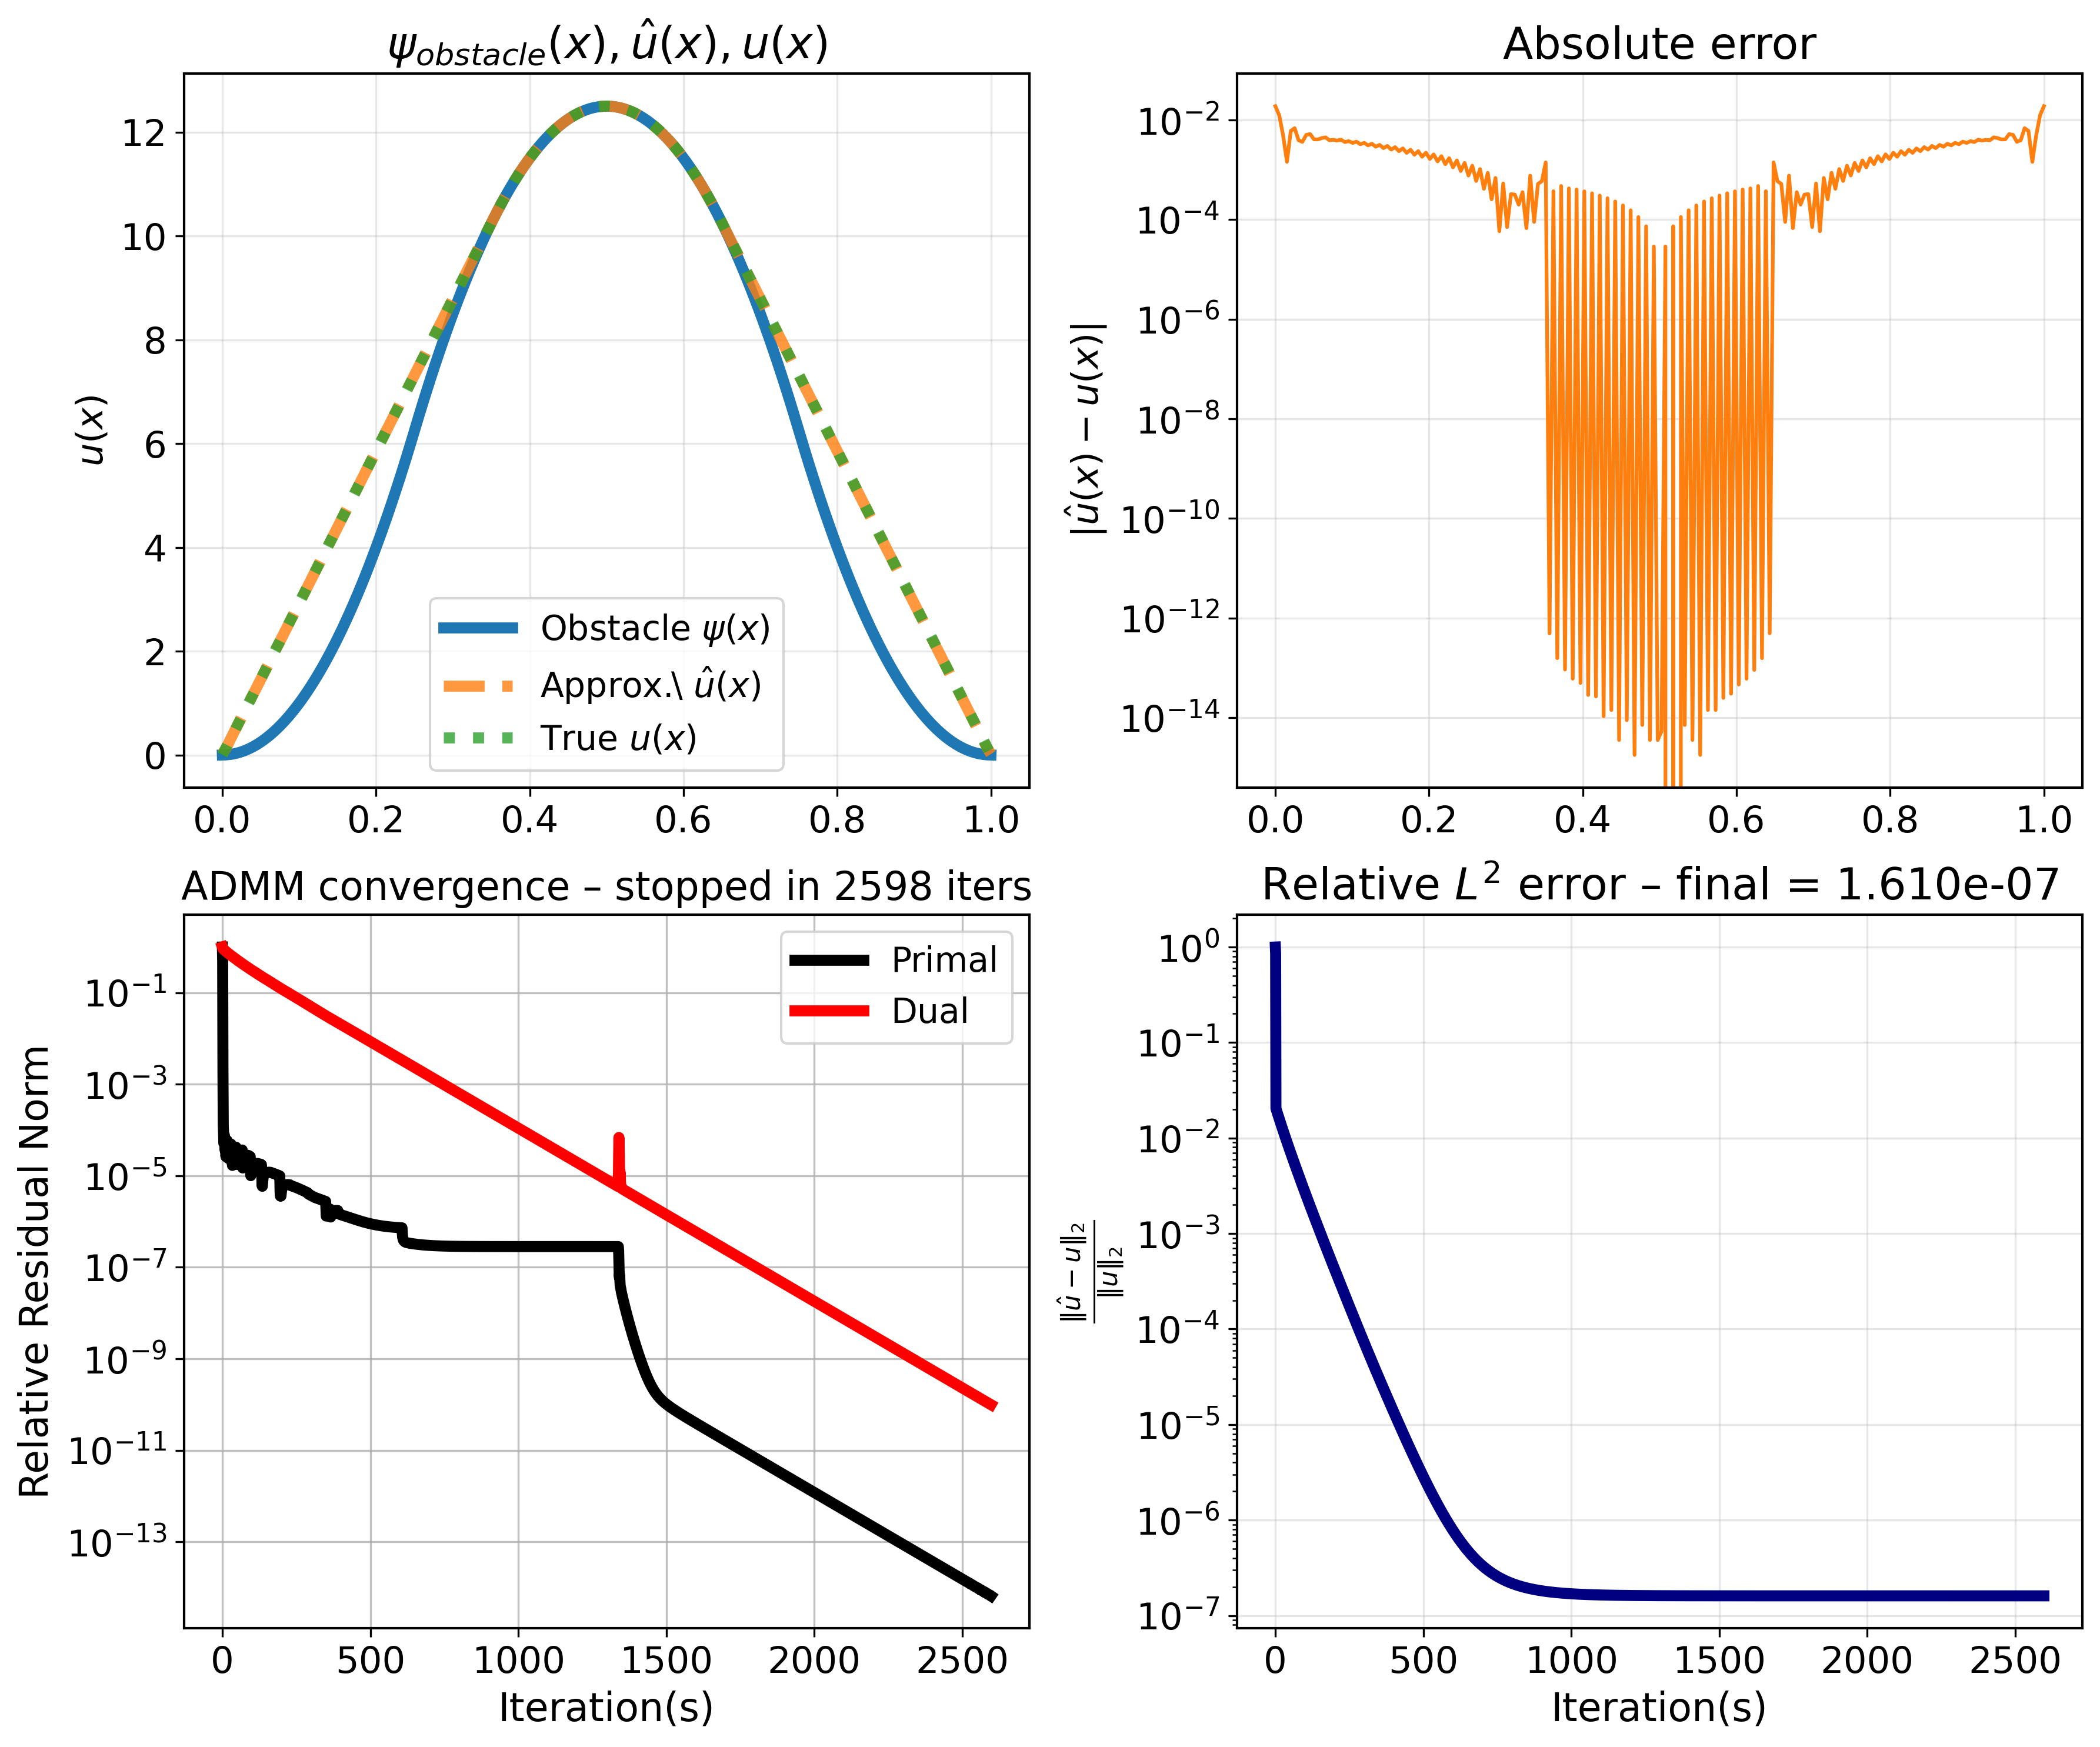

In [2]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})



# ── 1. convenience ----------------------------------------------------
iterations = np.arange(len(prim))
abs_err    = np.abs(u_final - u_true)

# ── 2. Figure & style (publication-ready) -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
lw = 4.5                  # desired line width

# ── (1, 1) obstacle / approx / true -----------------------------------
ax = axes[0, 0]
ax.plot(x, psi,     lw=lw, label=r'Obstacle $\psi(x)$', linestyle='-',  color='tab:blue')
ax.plot(x, u_final, lw=lw, label=r'Approx.\ $\hat{u}(x)$', linestyle='--', color='tab:orange', alpha=0.8)
ax.plot(x, u_true,  lw=lw, label=r'True $u(x)$',       linestyle=':',  color='tab:green',  alpha=0.8)

ax.set_title(r'$\psi_{obstacle}(x), \hat{u}(x), u(x)$', fontsize=18)
ax.set_ylabel(r'$u(x)$', fontsize = 15);  ax.grid(alpha=0.3)
ax.legend(fontsize=14)

# ── (1, 2) absolute error ---------------------------------------------
ax = axes[0, 1]
ax.semilogy(x, abs_err, lw=1.5, label=r'$\hat{u}(x) - u(x)$', color = 'tab:orange', linestyle = '-')
ax.set_title('Absolute error', fontsize=18)
ax.set_ylabel(r'$ | \hat{u}(x) - u(x) |$', fontsize = 15)
ax.grid(alpha=0.3)

# ── (2, 1) ADMM residuals ---------------------------------------------
ax = axes[1, 0]
ax.semilogy(iterations, prim, lw=lw, label='Primal', color = 'black')
ax.semilogy(iterations, dual, lw=lw, label='Dual', color = 'red')
ax.set_title(f'ADMM convergence – stopped in {it_conv} iters', fontsize=16)
ax.set_xlabel('Iteration(s)');  ax.set_ylabel('Relative Residual Norm');  ax.grid(alpha=0.8)
ax.legend(fontsize=14)

# ── (2, 2) relative L2 error ------------------------------------------
ax = axes[1, 1]
ax.semilogy(iterations, l2, lw=lw, color = 'navy')
ax.set_title(f'Relative $L^2$ error – final = {l2[-1]:.3e}', fontsize=18)
ax.set_xlabel('Iteration(s)');
ax.set_ylabel(r'$\frac{ \| \hat{u} - u \|_{2}}{\| u \|_{2} }$', fontsize = 15)
ax.grid(alpha=0.3)

# ── 3. global tweaks ---------------------------------------------------
for ax in axes.flat:
    ax.tick_params(labelsize=15)
fig.tight_layout()



if problem == '1':
    plt.savefig('fig_obstacle1D_single_bump.png')
    files.download('fig_obstacle1D_single_bump.png')
elif problem == '2':
    plt.savefig('fig_obstacle1D_two_bump.png')
    files.download('fig_obstacle1D_two_bump.png')

# Benchmark Performance Metrics

In [3]:
from __future__ import annotations
import time
import tracemalloc
import numpy as np
from numpy.linalg import svd
from numba import njit

# ------------------------------------------------------------------
# 1. obstacle & exact-solution factories
# ------------------------------------------------------------------
def _psi_u_factory(problem: str):
    """Return obstacle psi(x) and exact u(x) callables for the chosen case."""
    if problem == "1":                                           # single bump
        def psi(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 100*x[m1]**2
            y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 100*xs**2,
                              100*xs*(1-xs) - 12.5)
            return y

        def u_exact(x):
            x = np.asarray(x); y = np.zeros_like(x)
            xc = 1/(2*np.sqrt(2))
            m1 = (x <= xc)
            m2 = (x > xc) & (x <= .5)
            m3 = (x > 0.5)
            y[m1] = (100-50*np.sqrt(2))*x[m1]
            y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= xc, (100-50*np.sqrt(2))*xs,
                              100*xs*(1-xs) - 12.5)
            return y
        return psi, u_exact, dict(mu=300.0, rho=45.0)            # penalty pair

    if problem == "2":                                           # two bumps
        def psi(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 10*np.sin(2*np.pi*x[m1])
            y[m2] = 5*np.cos(np.pi*(4*x[m2]-1)) + 5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 10*np.sin(2*np.pi*xs),
                              5*np.cos(np.pi*(4*xs-1)) + 5)
            return y

        def u_exact(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 10*np.sin(2*np.pi*x[m1])
            y[m2] = 10.0
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 10*np.sin(2*np.pi*xs), 10.0)
            return y
        return psi, u_exact, dict(mu=2.5e4, rho=250.0)

    raise ValueError("problem must be '1' or '2'")


# ------------------------------------------------------------------
# 2. Gaussian RBF basis & its derivative (Numba-JIT)
# ------------------------------------------------------------------
@njit(fastmath=True)
def _phi_mat(b, N, x, c):
    m = x.size; phi = np.empty((m, N)); b2 = b*b; inv = 1/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i] - c[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True)
def _dphi_mat(b, N, x, c):
    m = x.size; dphi = np.empty((m, N)); b2 = b*b; two = 2*b2; inv = 1/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i] - c[j]
            dphi[i, j] = -two*d*np.exp(-b2*d*d)*inv
    return dphi


# ------------------------------------------------------------------
# 3. ADMM core (Numba-JIT, same as before but modular)
# ------------------------------------------------------------------
# --- JIT kernel with BC-rhs passed in ---------------------------------
@njit(fastmath=True)
def _admm(phi, psi, bc_rhs,          # <-- NEW: pre-assembled BC term
          U, S_inv, VT, mu, rho, beta, dx,
          u_true, max_iter, tol):

    def svd_solve(rhs):
        tmp = U.T @ rhs
        tmp *= S_inv
        return VT.T @ tmp

    N_, M = phi.shape[1], phi.shape[0]
    w = np.zeros(N_); v = phi @ w; z = np.zeros(M)
    v_prev = v.copy()

    norm_u2 = np.dot(u_true, u_true)

    for it in range(max_iter):
        # w-update
        rhs = rho * phi.T @ (v - z) + bc_rhs      # ← much simpler now
        w   = svd_solve(rhs)

        # v-update (projection + ℓ¹ prox)
        Pw = phi @ w
        ratio = mu*dx / rho
        for i in range(M):
            t = Pw[i] + z[i]
            if t < psi[i]:
                v[i] = psi[i] if t - ratio < psi[i] else t - ratio
            else:
                v[i] = t

        # z-update
        z += Pw - v

        # stopping checks
        r_k = Pw - v
        s_k = rho * (phi.T @ (v - v_prev))
        v_prev[:] = v
        prim = np.linalg.norm(r_k) / max(np.linalg.norm(Pw),
                                         np.linalg.norm(v), 1e-30)
        dual = np.linalg.norm(s_k) / max(np.linalg.norm(rho*phi.T@z), 1e-30)
        if prim < tol and dual < tol:
            rel_err = np.dot(Pw - u_true, Pw - u_true) / norm_u2
            return Pw, rel_err, it+1

    rel_err = np.dot(Pw - u_true, Pw - u_true) / norm_u2
    return Pw, rel_err, max_iter



# ------------------------------------------------------------------
# 4. Public driver
# ------------------------------------------------------------------
def obstacle_1d(*,
                problem: str = "1",
                N: int = 100,
                T: int = 2,
                c: float = 0.95,
                max_iter: int = 50_000,
                beta: float = 3e5,
                tau: float = 1e-15,
                tol: float = 1e-10):
    """
    Solve 1-D obstacle problem and return:
        (N, M, relative_error, computational_time_sec, memory_peak_MB)
    """
    # grids & basis
    M = T * N
    x = np.linspace(0.0, 1.0, M)
    centres = np.linspace(0.0, 1.0, N)
    dx = x[1] - x[0]
    b = c * N

    # obstacle + exact
    psi_fun, u_fun, penalties = _psi_u_factory(problem)
    psi = psi_fun(x)
    u_true = u_fun(x)
    mu, rho = penalties["mu"], penalties["rho"]

    # basis matrices
    phi  = _phi_mat(b, N, x, centres)
    dphi = _dphi_mat(b, N, x, centres)

    # weak BC data
    u0, u1b = u_true[0], u_true[-1]
    h_bc = 1e-6
    idx0 = np.where(x <= h_bc)[0]
    idx1 = np.where(x >= 1-h_bc)[0]
    phi0, phi1b = phi[idx0], phi[idx1]
    u0_vec, u1_vec = np.full(len(idx0), u0), np.full(len(idx1), u1b)
    W0 = dx*np.eye(len(idx0)); W1 = dx*np.eye(len(idx1))

    # system matrices
    # ----- inside obstacle_1d, just before the SVD ------------------------
    # ---------------------------------------------------------
    # assemble system (inside obstacle_1d)
    # ---------------------------------------------------------
    A1   = dphi.T @ dphi * dx             # stiffness
    Abc  = beta * (                       #  <-- restore BC matrix
        phi0.T @ W0 @ phi0 +
        phi1b.T @ W1 @ phi1b )

    bc_rhs = beta * (                     # BC vector (already OK)
        phi0.T @ (W0 @ u0_vec) +
        phi1b.T @ (W1 @ u1_vec) )

    lhs  = A1 + Abc + rho * (phi.T @ phi) #  <-- add Abc back in

    # SVD pre-factorisation
    U, S, VT = svd(lhs, full_matrices=False)
    S_inv = np.where(S > tau*S.max(), 1.0/S, 0.0)

    # -------------------------------------------------- timing + memory
    tracemalloc.start()
    t0 = time.perf_counter()

    u_num, rel_err, iters = _admm(
    phi, psi, bc_rhs,                # <-- NEW parameter
    U, S_inv, VT, mu, rho, beta, dx,
    u_true, max_iter, tol)

    comp_time = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    mem_peak_MB = peak / 1024**2

    return N, M, rel_err, comp_time, mem_peak_MB

In [4]:
    metrics = obstacle_1d(problem="1", N=100)
    print(f"N={metrics[0]},  M={metrics[1]},  rel_err={metrics[2]:.3e},  "
          f"time={metrics[3]:.2f}s,  mem={metrics[4]:.1f} MB")

N=100,  M=200,  rel_err=1.610e-07,  time=6.50s,  mem=8.2 MB


## Benchmark performance

In [43]:
N_values = [20, 40, 60, 80, 100, 120, 140, 160, 180]
c_vals = [95/n for n in N_values]
problem = "2"

In [44]:
import pandas as pd
records = []
for N, c in zip(N_values, c_vals):
  N_out, m, rel_error, comp_time, mem_peak_MB = obstacle_1d(problem=problem, N=N, c=c)
  print(f"N={N_out}, Gridsize m={m},  rel_err={rel_error:.3e},  "
        f"time={comp_time:.3f}s,  mem={mem_peak_MB:.3e} MB")
  records.append((dict(N = N_out,
                       m = m,
                       rel_error = rel_error,
                       comp_time = comp_time,
                       mem_peak_MB = mem_peak_MB)))

N=20, Gridsize m=40,  rel_err=1.129e+03,  time=4.118s,  mem=1.145e-02 MB
N=40, Gridsize m=80,  rel_err=4.226e-01,  time=0.043s,  mem=2.812e-02 MB
N=60, Gridsize m=120,  rel_err=2.068e-01,  time=0.235s,  mem=6.001e-02 MB
N=80, Gridsize m=160,  rel_err=2.838e-04,  time=3.960s,  mem=1.041e-01 MB
N=100, Gridsize m=200,  rel_err=5.856e-07,  time=8.652s,  mem=1.604e-01 MB
N=120, Gridsize m=240,  rel_err=3.363e-07,  time=14.689s,  mem=2.289e-01 MB
N=140, Gridsize m=280,  rel_err=3.180e-07,  time=19.842s,  mem=3.096e-01 MB
N=160, Gridsize m=320,  rel_err=4.104e-07,  time=24.113s,  mem=4.026e-01 MB
N=180, Gridsize m=360,  rel_err=5.880e-07,  time=31.472s,  mem=5.077e-01 MB


In [45]:
print(records)

[{'N': 20, 'm': 40, 'rel_error': 1128.996580160621, 'comp_time': 4.118196175999401, 'mem_peak_MB': 0.011453628540039062}, {'N': 40, 'm': 80, 'rel_error': 0.42263008810130515, 'comp_time': 0.04316783000012947, 'mem_peak_MB': 0.0281219482421875}, {'N': 60, 'm': 120, 'rel_error': 0.20682455890434942, 'comp_time': 0.23463205400003062, 'mem_peak_MB': 0.0600128173828125}, {'N': 80, 'm': 160, 'rel_error': 0.0002838380359980245, 'comp_time': 3.95979454099961, 'mem_peak_MB': 0.1041107177734375}, {'N': 100, 'm': 200, 'rel_error': 5.855684711458081e-07, 'comp_time': 8.652198994999708, 'mem_peak_MB': 0.1604156494140625}, {'N': 120, 'm': 240, 'rel_error': 3.362970302351354e-07, 'comp_time': 14.688623652999922, 'mem_peak_MB': 0.2289276123046875}, {'N': 140, 'm': 280, 'rel_error': 3.1797385101207475e-07, 'comp_time': 19.84228085900031, 'mem_peak_MB': 0.3096466064453125}, {'N': 160, 'm': 320, 'rel_error': 4.104241304791603e-07, 'comp_time': 24.11341705199993, 'mem_peak_MB': 0.4025726318359375}, {'N': 


---- collected data ----
  N   m rel_error comp_time mem_peak_MB
 20  40 1.129e+03     4.118   1.145e-02
 40  80 4.226e-01     0.043   2.812e-02
 60 120 2.068e-01     0.235   6.001e-02
 80 160 2.838e-04     3.960   1.041e-01
100 200 5.856e-07     8.652   1.604e-01
120 240 3.363e-07    14.689   2.289e-01
140 280 3.180e-07    19.842   3.096e-01
160 320 4.104e-07    24.113   4.026e-01
180 360 5.880e-07    31.472   5.077e-01


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Fitted models:
  memory ~ 1.555e-03·M + -0.11
  time   ~ N^2.035
  error  ~ N^-10.961


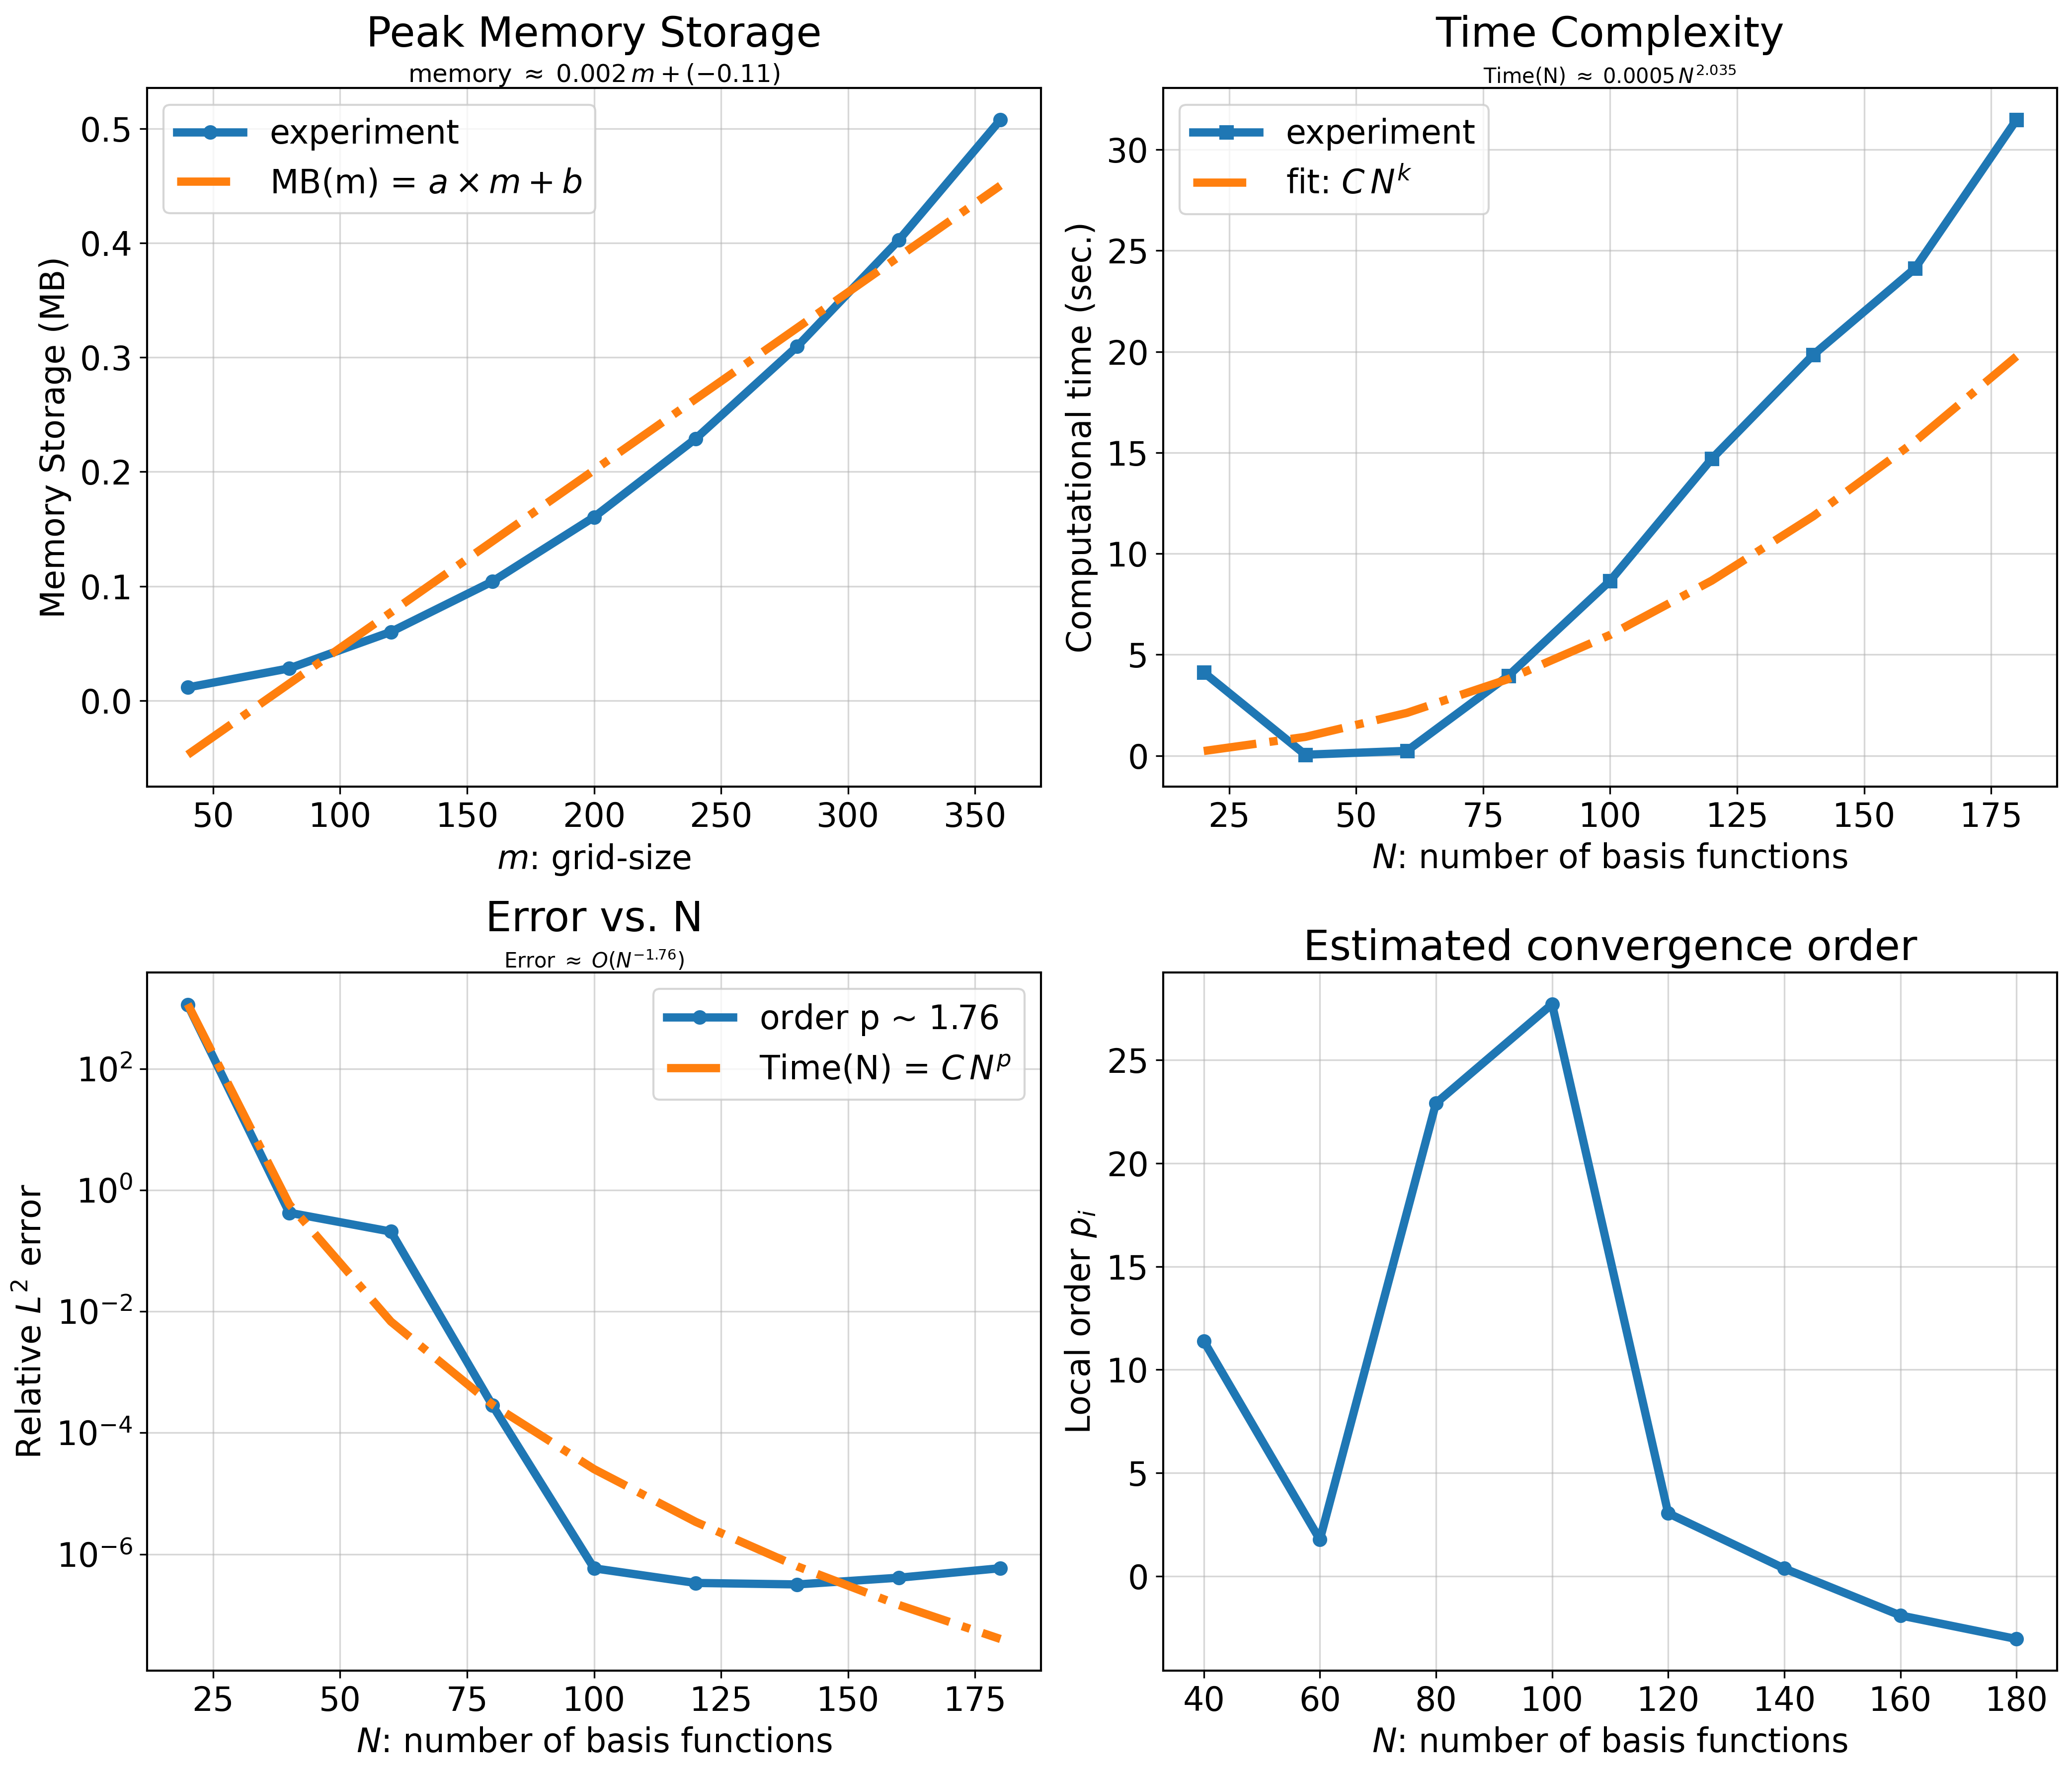

In [46]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


df = pd.DataFrame(records)
print("\n---- collected data ----")
print(df.to_string(index=False, formatters={
    "rel_error": "{:.3e}".format,
    "comp_time": "{:.3f}".format,
    "mem_peak_MB": "{:.3e}".format
}))



# ----------------------------------------------------------
# 3) prepare variables for fits / plots
# ----------------------------------------------------------
N_vals   = df["N"].to_numpy()
M_vals   = df["m"].to_numpy()
err_vals = df["rel_error"].to_numpy()
time_vals= df["comp_time"].to_numpy()
mem_vals = df["mem_peak_MB"].to_numpy()

# fits
a_mem, b_mem = np.polyfit(M_vals, mem_vals, 1)
mem_fit = a_mem * M_vals + b_mem

k_time, logC_time = np.polyfit(np.log(N_vals), np.log(time_vals), 1)
time_fit = np.exp(logC_time) * N_vals**k_time
Ctime = np.exp(logC_time)
p_err, logC_err = np.polyfit(np.log(N_vals), np.log(err_vals), 1)
err_fit = np.exp(logC_err) * N_vals**p_err
Cerror = np.exp(logC_err)
p_i  = -np.diff(np.log(err_vals)) / np.diff(np.log(N_vals))
N_mid = N_vals[1:]

# ----------------------------------------------------------
# 4) plotting (2 × 2 grid)
# ----------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# (top-left) memory vs M
axs[0, 0].plot(M_vals, mem_vals, "o-", label="experiment")
axs[0, 0].plot(M_vals, mem_fit, "-.", label=f"MB(m) = $a \\times m + b$")
axs[0, 0].set_xlabel("$m$: grid-size")
axs[0, 0].set_ylabel("Memory Storage (MB)")
axs[0, 0].set_title("Peak Memory Storage", pad = 20)
axs[0, 0].text(0.5, 1.0,
               rf"$\text{{memory}}\;\approx\;{a_mem:.3f}\,m + ({b_mem:.2f})$",
               ha="center", va="bottom", transform=axs[0, 0].transAxes,
               fontsize=12)
axs[0, 0].legend()
axs[0, 0].grid(True)

# (top-right) time vs N
axs[0, 1].plot(N_vals, time_vals, "s-", label="experiment")
axs[0, 1].plot(N_vals, time_fit, "-.", label=f"fit: $C\,N^k$")
axs[0, 1].set_xlabel("$N$: number of basis functions")
axs[0, 1].set_ylabel("Computational time (sec.)")
axs[0, 1].set_title("Time Complexity", pad = 20)
axs[0, 1].text(0.5, 1.00,
               rf"$\text{{Time(N)}}\;\approx\; {Ctime:.4f} \, N^{{{k_time:.3f}}}$",
               ha="center", va="bottom", transform=axs[0, 1].transAxes,
               fontsize=10)
axs[0, 1].legend()
axs[0, 1].grid(True)

# (bottom-left) error vs N (log scale)
axs[1, 0].plot(N_vals, err_vals, "o-", label=f"order p ~ $1.76$")
axs[1, 0].plot(N_vals, err_fit, "-.", label=f"Time(N) = $C\,N^p$")
axs[1, 0].set_yscale("log")
axs[1, 0].set_xlabel("$N$: number of basis functions")
axs[1, 0].set_ylabel("Relative $L^2$ error")
axs[1, 0].set_title("Error vs. N", pad = 20)
axs[1, 0].text(0.5, 1.00,
               rf"$\text{{Error}}\;\approx\; O(N^{{-1.76}})$",
               ha="center", va="bottom", transform=axs[1, 0].transAxes,
               fontsize=10)
axs[1, 0].legend()
axs[1, 0].grid(True)

# (bottom-right) local convergence order p_i
axs[1, 1].plot(N_mid, p_i, "-o")
axs[1, 1].set_xlabel("$N$: number of basis functions")
axs[1, 1].set_ylabel(r"Local order $p_i$")
axs[1, 1].set_title("Estimated convergence order")
axs[1, 1].grid(True)

fig.tight_layout()
if problem == "1":
  plt.savefig('fig2_obstacle_1d_benchmark_one_bump.png')
  files.download('fig2_obstacle_1d_benchmark_one_bump.png')
elif problem == "2":
  plt.savefig('fig2_obstacle_1d_benchmark_two_bumps.png')
  files.download('fig2_obstacle_1d_benchmark_two_bumps.png')
#plt.show()

# ----------------------------------------------------------
# 5) print fitted exponents
# ----------------------------------------------------------
print("\nFitted models:")
print(f"  memory ~ {a_mem:.3e}·M + {b_mem:.2f}")
print(f"  time   ~ N^{k_time:.3f}")
print(f"  error  ~ N^{p_err:.3f}")